In [54]:
from pathlib import Path
import subprocess
from collections import Counter
from itertools import combinations


import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [55]:
data = Path().resolve() / 'mash'

In [56]:
# cmd = f"""
# source activate mash \
#     && bsub \
#         -o {data / 'mash.out'} \
#         -e {data / 'mash.err'} \
#             "mash \
#                 triangle \
#                 -k 21 \
#                 -s 10000 \
#                 -l {data.parent / 'input.txt'} \
#                 > {data / 'dist.tsv'}
#             "
# """
# subprocess.run(cmd, shell=True)

In [57]:
with open(data / 'dist.tsv') as file:
    mash = [[value.strip() for value in row.split('\t')] for row in file.readlines()][1:]

In [58]:
names = [Path(row[0]).stem for row in mash]

In [59]:
distances = [value for row in mash for value in row[1:]]

In [60]:
matrix = np.zeros((len(mash), len(mash)))
matrix[np.tril_indices_from(matrix, k=-1)] = distances
matrix = matrix + matrix.T
m = squareform(matrix)
z = linkage(m, 'single')

In [61]:
def dunn_index(cutoff):
    clusters = fcluster(z, cutoff, 'distance')
    cluster_labels = [item for item, count in Counter(clusters).items() if count > 1]
    
    avg_intra_cluster_distances = []
    for label in cluster_labels:
        idx = clusters == label
        subset = matrix[np.ix_(idx, idx)]
        avg_intra_cluster_distances.append(np.mean(subset[np.tril_indices_from(subset, k=-1)]))
    max_intra_cluster_distance = max(avg_intra_cluster_distances)
    
    avg_inter_cluster_distances = []
    for a, b in combinations(cluster_labels, 2):
        idx_a = clusters == a
        idx_b = clusters == b
        avg_inter_cluster_distances.append(np.mean(matrix[np.ix_(idx_a, idx_b)]))
    min_inter_cluster_distance = min(avg_inter_cluster_distances)
    
    dunn_index = min_inter_cluster_distance / max_intra_cluster_distance
    return {cutoff : dunn_index}

In [62]:
dunn_idx = {k:v for i in range(0, 105, 5) for k, v in dunn_index(i /1000).items()}

/tmp/ipykernel_3338448/1590180031.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  dunn_index = min_inter_cluster_distance / max_intra_cluster_distance


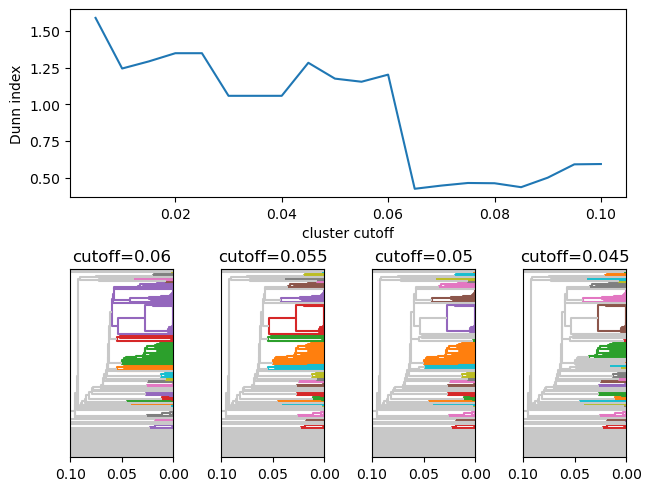

In [63]:
fig = plt.figure(constrained_layout=True)
grid = fig.add_gridspec(2,4)
a = fig.add_subplot(grid[0,:])
sns.lineplot(x=dunn_idx.keys(), y=dunn_idx.values(), ax=a)
a.set(xlabel='cluster cutoff', ylabel='Dunn index')

b = fig.add_subplot(grid[1,0])
c = fig.add_subplot(grid[1,1])
d = fig.add_subplot(grid[1,2])
e = fig.add_subplot(grid[1,3])


dendrogram(z, no_labels=True, orientation='left', color_threshold=0.06, above_threshold_color="#C8C8C8", ax=b)
dendrogram(z, no_labels=True, orientation='left', color_threshold=0.055, above_threshold_color="#C8C8C8", ax=c)
dendrogram(z, no_labels=True, orientation='left', color_threshold=0.05, above_threshold_color="#C8C8C8", ax=d)
dendrogram(z, no_labels=True, orientation='left', color_threshold=0.045, above_threshold_color="#C8C8C8", ax=e)


b.set_title('cutoff=0.06')
b.set_xlim(.1)
c.set_title('cutoff=0.055')
c.set_xlim(.1)
d.set_title('cutoff=0.05')
d.set_xlim(.1)
e.set_title('cutoff=0.045')
e.set_xlim(.1)
plt.savefig(data / 'mash_sensitivity.pdf', bbox_inches='tight')

In [64]:
# cmd = f"""
# source activate mash \
#     && bsub \
#         -o {data / 'mash.out'} \
#         -e {data / 'mash.err'} \
#             "mash \
#                 triangle \
#                 -E \
#                 -k 21 \
#                 -s 10000 \
#                 -l {data.parent / 'input.txt'} \
#                 > {data / 'mash_edges.tsv'}
#             "
# """
# subprocess.run(cmd, shell=True)